# **Project Name**    - Retail Sales Prediction

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import calendar
from numpy import math
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import  StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import ttest_ind,ttest_1samp,t,norm
import eda
import warnings
warnings.filterwarnings('ignore')

/tmp/ipykernel_43594/3078686734.py:4: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  from numpy import math


# **Rossmann Stores Data**

### ***1. Know Your Data***

### Dataset Loading

In [2]:
# Load Dataset
pd.set_option("display.max_columns", None)
path_rossmann = 'data/Rossmann Stores Data.csv'
path_store = 'data/store.csv'
df_rossmann = pd.read_csv(path_rossmann)
df_store = pd.read_csv(path_store)
df_merged = df_rossmann.merge(df_store, on="Store", how="left")
df = df_merged.copy()
print(f"shape rossmann : {df_rossmann.shape}")
print(f"shape store : {df_store.shape}")
print(f"duplicates rossmann : {df_rossmann.duplicated().sum()}")
print(f"duplicates store : {df_store.duplicated().sum()}")
print()
print("----- Rossmann -----")
print(df_rossmann.head(3))
print()
print()
print("----- Store -----")
print(df_store.head(3))
print("-"*30 +"MERGED DATA"+ "-"*30)
print(f"df : {df.shape}")
print(f"df : {df.duplicated().sum()}")
print()
print(df.head(2))

shape rossmann : (1017209, 9)
shape store : (1115, 10)
duplicates rossmann : 0
duplicates store : 0

----- Rossmann -----
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  


----- Store -----
   Store StoreType Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
0      1         c          a               1270.0                        9.0   
1      2         a          a                570.0                       11.0   
2      3         a          a              14130.0                       12.0   

   CompetitionOpenSinceYear  Promo2  Promo2SinceWeek  Promo2SinceYear  \
0                    2008.0       0              NaN              N

### Dataset Rows & Columns count, Duplicate values, Missing, Unique value count

In [3]:
print("-"*20+" Columns "+"-"*20)
print(f"columns : {list(df.columns)}")
print()
print("-"*20+" Nulls "+"-"*20)
print(f"null count:\n{df.isna().mean()}")
print()
print("-"*20+" Uniques "+"-"*20)
print(f"unique count:\n{df.nunique()}")

-------------------- Columns --------------------
columns : ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

-------------------- Nulls --------------------
null count:
Store                        0.000000
DayOfWeek                    0.000000
Date                         0.000000
Sales                        0.000000
Customers                    0.000000
Open                         0.000000
Promo                        0.000000
StateHoliday                 0.000000
SchoolHoliday                0.000000
StoreType                    0.000000
Assortment                   0.000000
CompetitionDistance          0.002597
CompetitionOpenSinceMonth    0.317878
CompetitionOpenSinceYear     0.317878
Promo2                       0.000000
Promo2SinceWeek              0.499

### Dataset Information

In [4]:
# Dataset Info
print("-"*20+" Info "+"-"*20)
print(df.info())

-------------------- Info --------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMon

1. The dataset has 1017209 and 18 columns.
2. There is no duplicate row.
3. Missing values proportions in the following columns:
   - CompetitionOpenSinceMonth : 0.32
   - CompetitionOpenSinceYear : 0.32
   - Promo2SinceWeek : 0.50
   - Promo2SinceYear : 0.50
   - PromoInterval : 0.50

## ***2. Understanding The Variables***

In [5]:
# Dataset Describe
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print("-"*20+" Description "+ "-"*20)
print(df.describe())

-------------------- Description --------------------
           Store  DayOfWeek      Sales  Customers       Open      Promo  \
count 1017209.00 1017209.00 1017209.00 1017209.00 1017209.00 1017209.00   
mean      558.43       4.00    5773.82     633.15       0.83       0.38   
std       321.91       2.00    3849.93     464.41       0.38       0.49   
min         1.00       1.00       0.00       0.00       0.00       0.00   
25%       280.00       2.00    3727.00     405.00       1.00       0.00   
50%       558.00       4.00    5744.00     609.00       1.00       0.00   
75%       838.00       6.00    7856.00     837.00       1.00       1.00   
max      1115.00       7.00   41551.00    7388.00       1.00       1.00   

       SchoolHoliday  CompetitionDistance  CompetitionOpenSinceMonth  \
count     1017209.00           1014567.00                  693861.00   
mean            0.18              5430.09                       7.22   
std             0.38              7715.32             

### Variables Description 

1. CompetitionDistance : Mean is 5430 and median is 2330 this indicates presence of outliers in this column.
2. DayOfWeek : Day in numbers like 1 for monday, 2 for tuesday etc. Mean and median for this column is same.
3. Sales : Number of sales for particular data. Mean is 5773 and median is 5744.
4. Customers : Number of customers for perticular date. Mean is 633 and median is 609.
5. Open : Whether the shop was open or not  for the perticular date. It is a binary column.
6. Promo  : A binary column.
8. Holiday : A binary column indicates holiday for a perticular date.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [6]:
class Eda:
    def __init__(self):
        pass
    def get_specific_col(self, df:pd.DataFrame, main_type=None, sub_type=None):
        if main_type == "numerical":
            numerical_columns = list(df.describe(include="number").columns)
            if not sub_type:
                return numerical_columns
            binary_columns = [col for col in numerical_columns if df[col].nunique()==2]
            discrete_columns = [col for col in numerical_columns if df[col].nunique()<32]
            if sub_type == "binary":
                return binary_columns
            elif sub_type == "discrete":
                return discrete_columns
            elif sub_type == "continous":
                continous_columns = [col for col in numerical_columns if col not in binary_columns + discrete_columns]
                return continous_columns
            elif sub_type == "temporal":
                temporal_columns = ["Date", "DayOfWeek", "CompetitionOpenSinceMonth",
                                    "CompetitionOpenSinceYear", "Promo2SinceWeek", "Promo2SinceYear"]
                return temporal_columns
        elif main_type == "categorical":
            categorical_columns = list(df.describe(exclude="number").columns)
            return categorical_columns
        else:
            return []

In [7]:
print("Data distribution of open closed:")
print(f"{df['Open'].value_counts()}")

Data distribution of open closed:
Open
1    844392
0    172817
Name: count, dtype: int64


In [8]:
# # Assigning copy of final_df to a variable
# display(df[df['Open']==0].head()) # when shops are closed then customers and sales are 0. Therefore I decided to drop them.
# df = df[df['Open'] == 1] # drop the rows where Open = 0.
# df.drop('Open', axis=1, inplace = True) # drop Open bacause now there is only 1 value.
# print('shape after dropping values for Open = 0 : ',df.shape)

In [9]:
# Function to get top ten sum
df['Date'] = df["Date"].apply(lambda x:datetime.strptime(x, '%Y-%m-%d').date()) # Convert Date column from string to datetime format
df['year'] = df['Date'].apply(lambda x: x.year) # Fetching year from Date
top10storesWithHighestSales = df.groupby(['Store'])['Sales'].sum().sort_values(ascending=False).head(10)
top10storesWithHighestCustomers = df.groupby(['Store'])['Customers'].sum().sort_values(ascending=False).head(10)
meanSalesForStateHoliday = df.groupby(['StateHoliday'])['Sales'].sum().sort_values(ascending=False)
meanSalesForSchoolHoliday = df.groupby(['SchoolHoliday'])['Sales'].sum().sort_values(ascending=False)
meanSalesForDayOfWeek = df.groupby(['DayOfWeek'])['Sales'].sum().sort_values(ascending=False)
meanSalesForPromo = df.groupby(['Promo'])['Sales'].sum().sort_values(ascending=False)

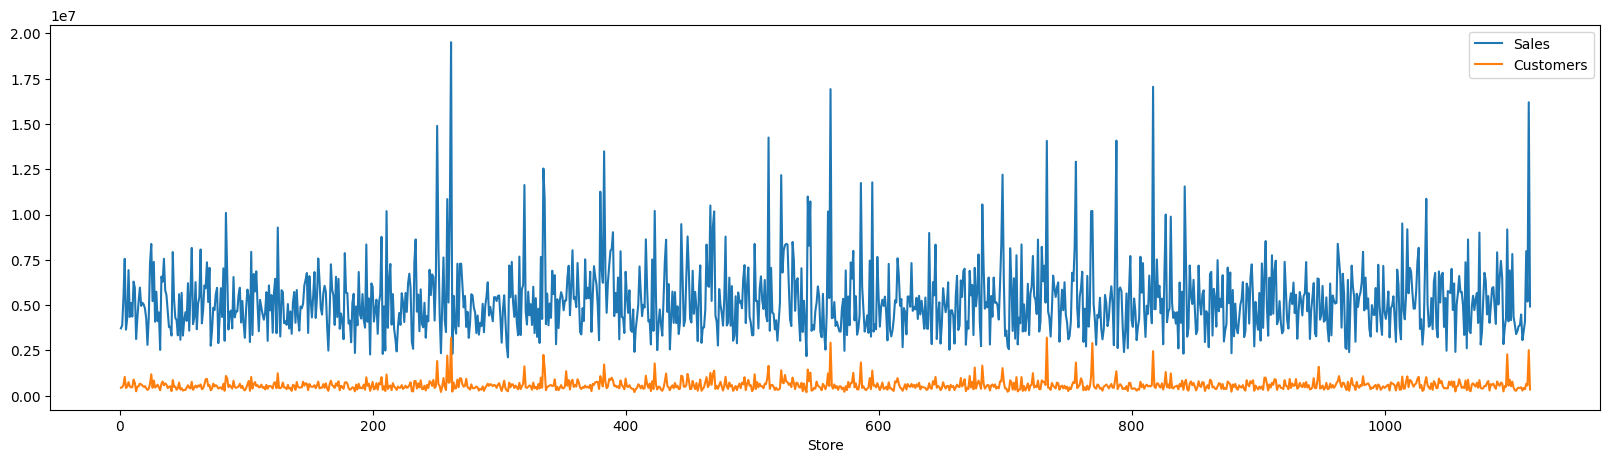

In [10]:
df.groupby(["Store"])[["Sales", "Customers"]].sum().sort_index().plot.line(figsize=(20,5))
plt.show()

In [11]:
print("Sum of the sales when shops are closed :",df[df["Open"]==0]["Sales"].sum())
print("Sum of the sales when shops are opened :",df[df["Open"]==1]["Sales"].sum())

Sum of the sales when shops are closed : 0
Sum of the sales when shops are opened : 5873180623


In [12]:
top10storesWithHighestSales.reset_index(name='sum_sales')

,Store,sum_sales
0,262,19516842
1,817,17057867
2,562,16927322
3,1114,16202585
4,251,14896870
5,513,14252406
6,788,14082141
7,733,14067158
8,383,13489879
9,756,12911782


In [13]:
top10storesWithHighestCustomers.reset_index(name='sum_customers')

,Store,sum_customers
0,733,3206058
1,262,3204694
2,562,2924960
3,769,2902351
4,1114,2509542
5,817,2454370
6,1097,2280508
7,335,2246936
8,259,2210980
9,251,1908934


In [14]:
meanSalesForStateHoliday.reset_index(name='MeanSale')

,StateHoliday,MeanSale
0,0,5113659442
1,0,751505326
2,a,5890305
3,b,1433744
4,c,691806


In [15]:
meanSalesForSchoolHoliday.reset_index(name='MeanSale')

,SchoolHoliday,MeanSale
0,0,4696260531
1,1,1176920092


In [16]:
meanSalesForPromo.reset_index(name='MeanSale')

,Promo,MeanSale
0,1,3101206286
1,0,2771974337


In [17]:
meanSalesForDayOfWeek.reset_index(name='MeanSale')

,DayOfWeek,MeanSale
0,1,1130203012
1,2,1020411930
2,5,980555941
3,3,954962863
4,4,911177709
5,6,846317735
6,7,29551433


In [18]:
eda.getMeanMedian(df, 'year', 2013)

,mean,50%
Store,558.00,558.00
DayOfWeek,3.99,4.00
Sales,5658.53,5598.00
Customers,629.04,603.00
Open,0.83,1.00
Promo,0.37,0.00
SchoolHoliday,0.19,0.00
CompetitionDistance,5404.91,2330.00
CompetitionOpenSinceMonth,7.22,8.00
CompetitionOpenSinceYear,2008.67,2010.00


In [19]:
eda.getMeanMedian(df, 'year', 2014)

,mean,50%
Store,559.17,559.00
DayOfWeek,4.00,4.00
Sales,5833.29,5794.00
Customers,643.27,619.00
Open,0.83,1.00
Promo,0.38,0.00
SchoolHoliday,0.19,0.00
CompetitionDistance,5473.40,2330.00
CompetitionOpenSinceMonth,7.22,8.00
CompetitionOpenSinceYear,2008.73,2010.00


In [20]:
eda.getMeanMedian(df, 'year', 2015)

,mean,50%
Store,558.00,558.00
DayOfWeek,4.00,4.00
Sales,5878.25,5916.00
Customers,624.20,606.00
Open,0.83,1.00
Promo,0.40,0.00
SchoolHoliday,0.15,0.00
CompetitionDistance,5404.90,2325.00
CompetitionOpenSinceMonth,7.22,8.00
CompetitionOpenSinceYear,2008.67,2010.00


### What all manipulations have you done and insights you found?

1. First of all I displayed the data when Store are not open and found that when stores are not open then number of customers and sales are 0.
2. Then I decided to drop the rows where Open = 0. After that I dropped Open column.
3. Top store with highest sum of sale is 262 with 19516842 number of sales.
4. Top store with highest sum of customer is 733 with 3206058 number of customers.
5. Mean sale is 4 times higher when there is no school holiday.
6. Mean sales for day 7 is least. It is because of sunday and holiday.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Target column distribution plot

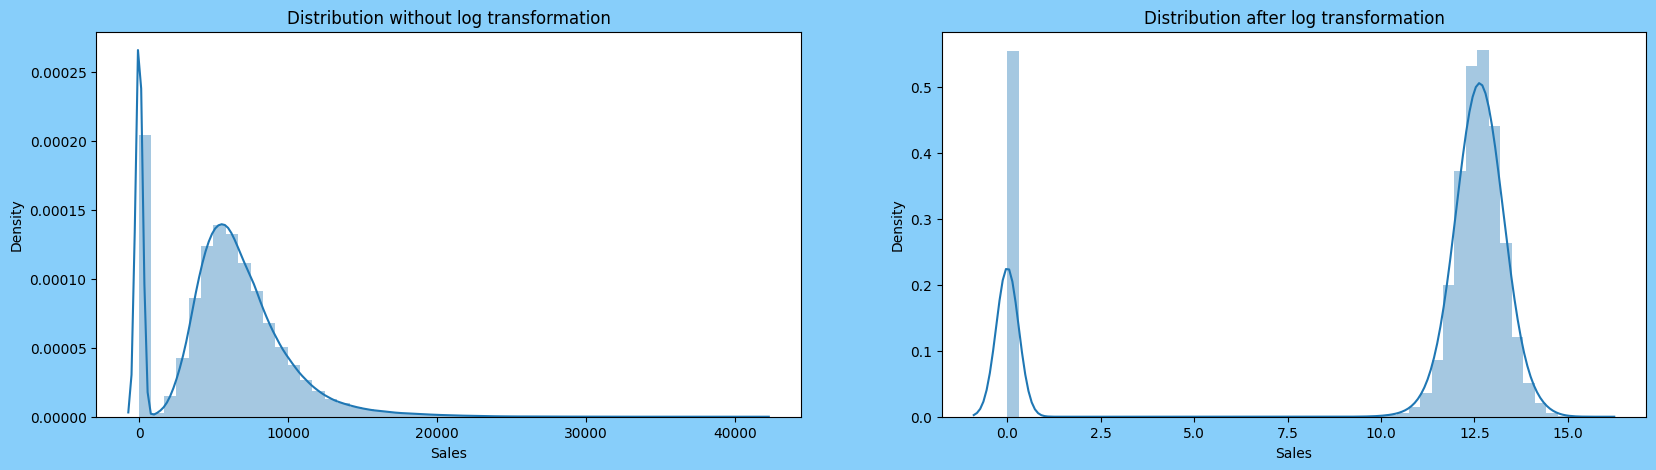

In [21]:
# Chart - 1 visualization code
facecolor = 'lightskyblue'
fig, axes = plt.subplots(ncols=2, nrows=1, facecolor=facecolor, figsize=(20,5))
sns.distplot(df['Sales'], ax=axes[0]) # Without log-transformation
axes[0].set_title('Distribution without log transformation')
sns.distplot(np.log2(df['Sales']+1), ax=axes[1]) # After log-transformation
axes[1].set_title('Distribution after log transformation')
plt.show()

1. Distribution charts shows how data is distributed on the axis. I picked this chart to check the distribution about the target variable.
2. From the above chart I found that Sales column was very close to normal distribution and After log transformation I found that the distribution became more close to Normal distribution except the 0 part this is happening because that time shop is closed.
3. Since the column is normally distributed and it is ideal for ML model building.

#### Chart - 2 - Pie chart groupby day of week and sales.

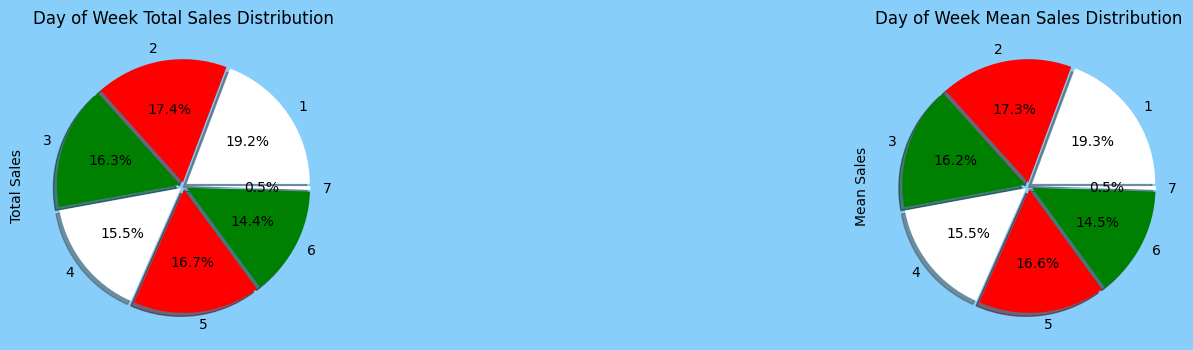

In [22]:
# Chart - 2 visualization code
fig, axes = plt.subplots(nrows=1, ncols=2, facecolor=facecolor, figsize=(20, 4))
df.groupby(['DayOfWeek'])['Sales'].sum().plot.pie(ax=axes[0],shadow =True,explode=[0.03,0.03,0.03,0.03,0.03,0.03,0.03], autopct='%0.1f%%',colors={'red','white','green'})
df.groupby(['DayOfWeek'])['Sales'].mean().plot.pie(ax=axes[1],shadow =True,explode=[0.03,0.03,0.03,0.03,0.03,0.03,0.03], autopct='%0.1f%%',colors={'red','white','green'})
axes[0].set_title('Day of Week Total Sales Distribution')
axes[0].set_ylabel("Total Sales")

axes[1].set_title('Day of Week Mean Sales Distribution')
axes[1].set_ylabel("Mean Sales")
plt.show()

1. Pie chart shows part to whole relationship in the data. I picked this chart to see percentage of Sales for different days.
2. I found sum and mean sales on day 1 (Monday) is highest but on day 7 (Sunday) is least due to weekend.
3. The pattern I found here is sales are almost equal for each day except sunday. We can drop this column and create a new feature isSunday or isDay7.

#### Chart - 3 - Pie chart Groupby Promo and Sales

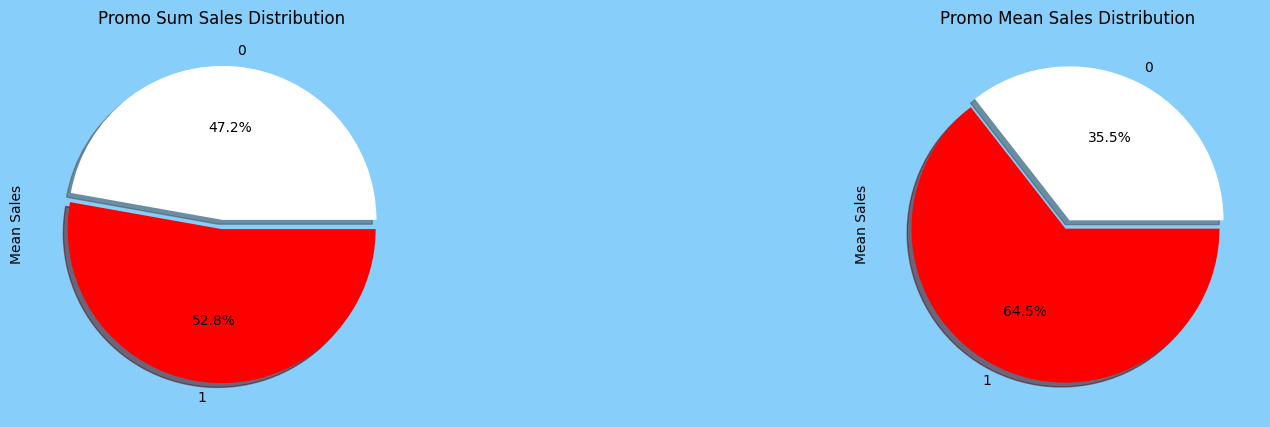

In [23]:
# Chart - 3 visualization code
fig, axes = plt.subplots(nrows=1, ncols=2, facecolor=facecolor, figsize=(20, 5))
df.groupby(['Promo'])['Sales'].sum().plot.pie(ax=axes[0],
                                              shadow =True,explode=[0.03,0.03],
                                              autopct='%0.1f%%',colors={'red','white','green'})
df.groupby(['Promo'])['Sales'].mean().plot.pie(ax=axes[1],
                                               shadow =True,explode=[0.03,0.03],
                                               autopct='%0.1f%%',colors={'red','white','green'})

axes[0].set_title('Promo Sum Sales Distribution')
axes[0].set_ylabel("Mean Sales")

axes[1].set_title('Promo Mean Sales Distribution')
axes[1].set_ylabel("Mean Sales")
plt.show()

1. Percentage of sum of the Promo sales 52% while non-promo sales is 47%
2. Percentage of mean of the Promo sales 64% while non-promo sales is 35%
3. I found that when non-promo the sale is lower therefore promo play important role with sales.

#### Chart - 4 - Pie chart groupby school holiday and sales.

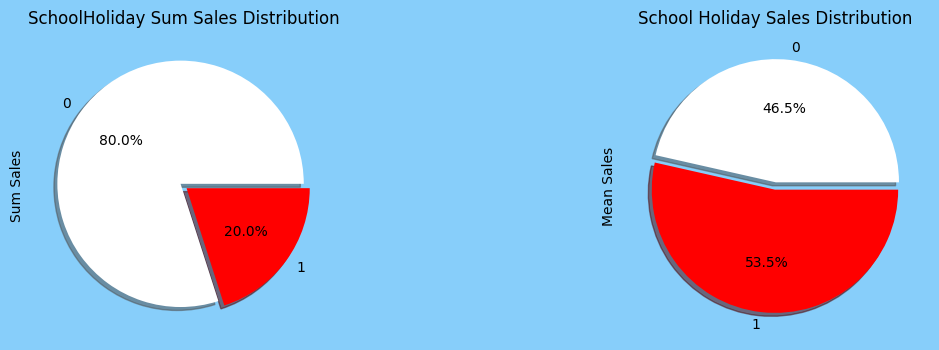

In [24]:
# Chart - 4 visualization code
fig, axes = plt.subplots(nrows=1, ncols=2, facecolor=facecolor, figsize=(14, 4))
df.groupby(['SchoolHoliday'])['Sales'].sum().plot.pie(ax=axes[0],shadow =True,explode=[0.03,0.03], autopct='%0.1f%%',colors={'red','white','green'})
df.groupby(['SchoolHoliday'])['Sales'].mean().plot.pie(ax=axes[1],shadow =True,explode=[0.03,0.03], autopct='%0.1f%%',colors={'red','white','green'})
axes[0].set_title('SchoolHoliday Sum Sales Distribution')
axes[0].set_ylabel("Sum Sales")

axes[1].set_title('School Holiday Sales Distribution')
axes[1].set_ylabel("Mean Sales")
plt.show()

1. Average sale for holiday is 53% and for non holiday is 46%.
2. Sum of the % for holiday is 80% and for non holiday is 20%.
3. School holiday leading to more sales it might be because there are lot of teenage students who are important customers.

#### Chart - 5 - Pie chart groupby State Holiday and sales.

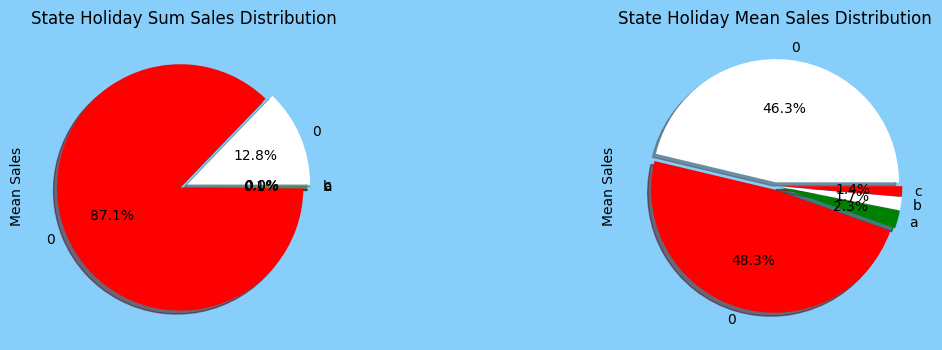

In [25]:
# Chart - 5 visualization code
fig, axes = plt.subplots(nrows=1, ncols=2, facecolor=facecolor, figsize=(14, 4))
df.groupby(['StateHoliday'])['Sales'].sum().plot.pie(ax=axes[0],shadow =True,explode=[.03,.03,.03,.03,.03], autopct='%0.1f%%',colors={'red','white','green'})
df.groupby(['StateHoliday'])['Sales'].mean().plot.pie(ax=axes[1],shadow =True,explode=[.03,.03,.03,.03,.03], autopct='%0.1f%%',colors={'red','white','green'})
axes[0].set_title('State Holiday Sum Sales Distribution')
axes[0].set_ylabel("Mean Sales")

axes[1].set_title('State Holiday Mean Sales Distribution')
axes[1].set_ylabel("Mean Sales")
plt.show()

1. Percentage of mean Sale of the state holiday 0 is 46.3%, for '0' 48.3%, for a 2.3%, for b 17% and for c 14%.
2. Percentage of sum of the states sales more than 87% when there is no holidays in state and state type '0'. Only few percentage of sales happened during holiday a,b,c. I think a,b,c are state festival and that day customers busy celebrating the festivals therefore those days are not good for business.
3. I think there is some wrong entry numeric 0 and str 0 both should be same I have to replace the numeric to str 0

Chart 6 - Yearwise Sales

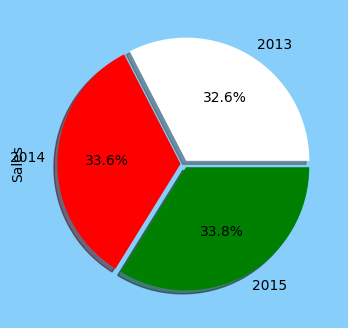

In [26]:
# Chart - 11 visualization code
plt.figure(facecolor=facecolor, figsize=(4,4))
df.groupby(['year'])['Sales'].mean().plot.pie(shadow =True,explode=[0.03,0.03,.03], autopct='%0.1f%%',colors={'red','white','green'})
plt.show()

1. Average sale for 2013,2014 and 2015 is almost equal which is nearly 33%.
2. Sales for each year is almost same.

#### Chart - 7 - Histpolot and KDE plot

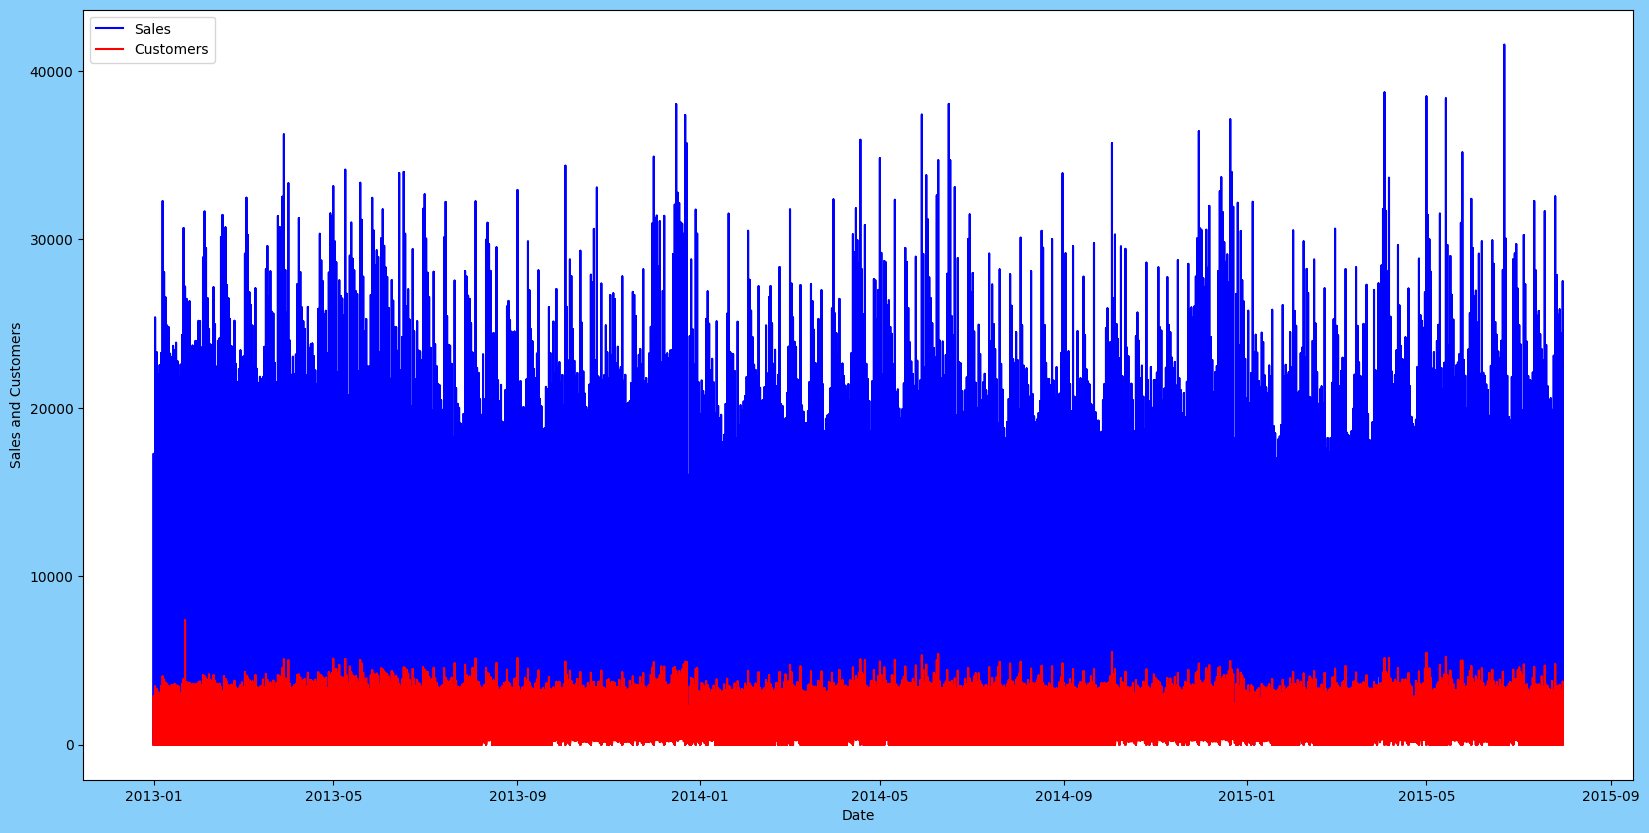

In [27]:
plt.figure(figsize=(20,10), facecolor=facecolor)
plt.plot(df['Date'],df['Sales'],label='Sales', color='blue')
plt.plot(df['Date'],df['Customers'],label='Customers', color='red')
plt.xlabel('Date')
plt.ylabel('Sales and Customers')
plt.legend()
plt.show()

I picked this chart to see seasonality of the data and found that the data follows seasonality which is ideal for TimeSeries model.

#### Chart - 8

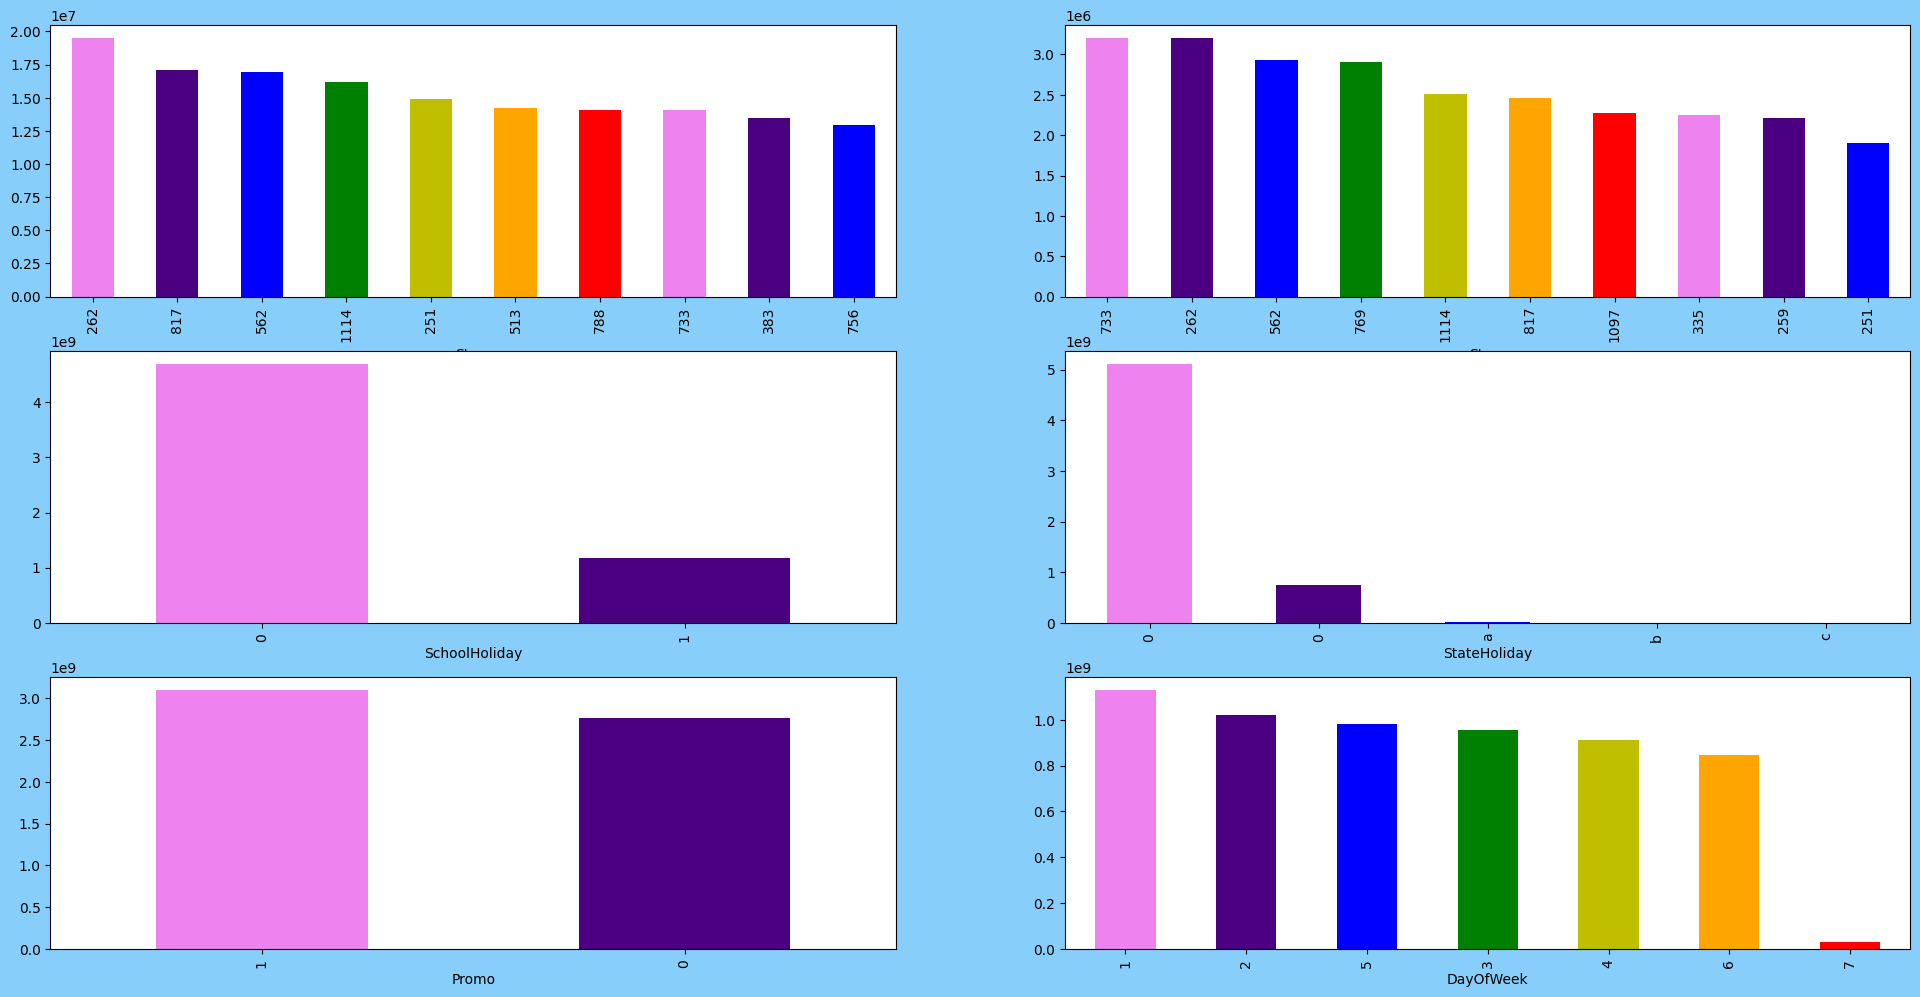

In [28]:
# Chart - 12 visualization code
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(24,12), facecolor=facecolor)
colors = ['violet','indigo','b','g','y','orange','r']
top10storesWithHighestSales.plot.bar(ax=axes[0][0], color=colors)
top10storesWithHighestCustomers.plot.bar(ax=axes[0][1], color=colors)
meanSalesForSchoolHoliday.plot.bar(ax=axes[1][0], color=colors)
meanSalesForStateHoliday.plot.bar(ax=axes[1][1], color=colors)
meanSalesForPromo.plot.bar(ax=axes[2][0], color=colors)
meanSalesForDayOfWeek.plot.bar(ax=axes[2][1], color=colors)
plt.show()

#### Chart - 9 - Correlation Heatmap

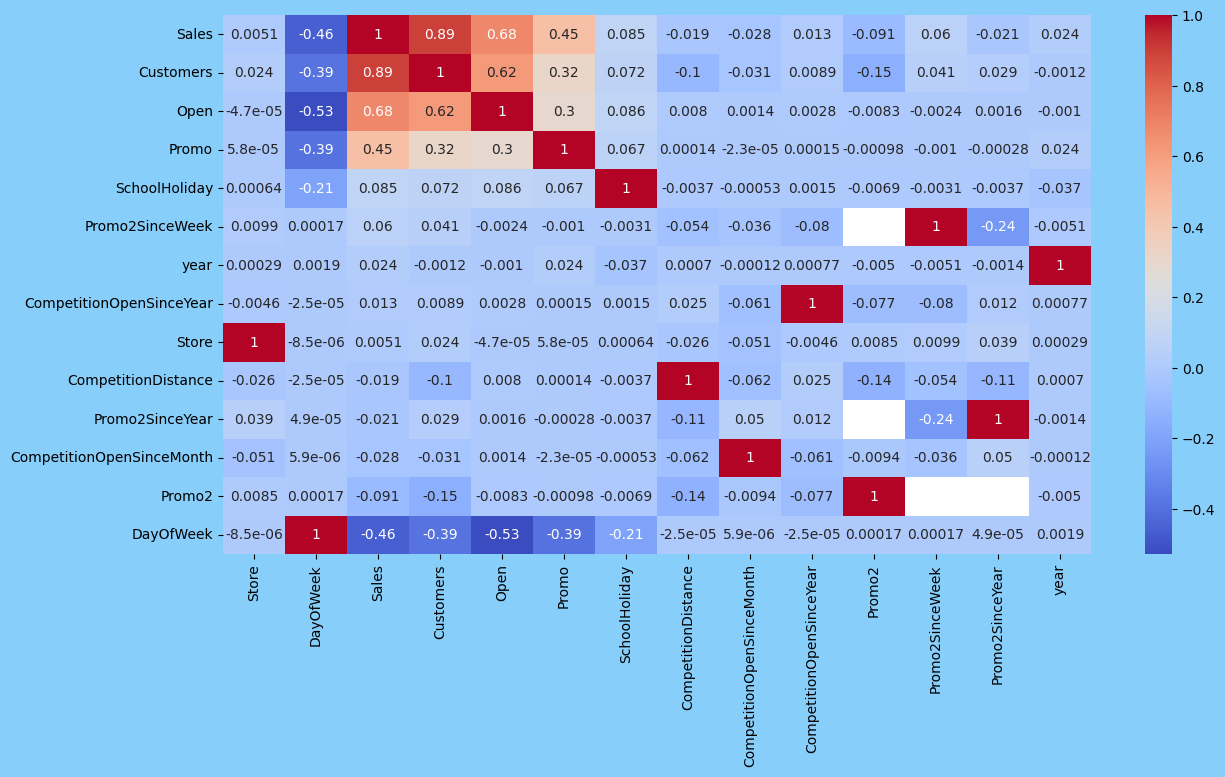

In [29]:
plt.figure(figsize=(14,7), facecolor=facecolor)
num_cols = df.describe(include="number").columns
# num_cols = ['Sales', 'Customers','SchoolHoliday', 'DayOfWeek', 'Promo']
corr = df[num_cols].corr()
sns.heatmap(corr.sort_values(by="Sales", ascending=False), cmap='coolwarm', annot=True)
plt.show()

Sales is our target column while Customers is independent variable and the correlation between target and independent variable is 82%. Which shows by using this one independent variable we can explain 82% variability in target variable but hold on. In real world it is not possible to get number of customers before purchase happened therefore this variable could lead to good accuracy for the data which is aleady present in database but in real time sales and customers comes together.

#### Chart - 10 - Pair Plot 

In [30]:
# Pair Plot visualization code   
# sns.pairplot(df[num_cols])
# plt.show()

1. Pair chart gives very good visualization of realtionship between two variables which is very important to select and understand the variables I picked this chart to see the relationship between the variables.
2. I found that only Sales and Customers has linear relationship.

In [31]:
# df.to_csv('cleaned_data/rossmann_eda_done.csv') # save the dataset after eda

# **Conclusion**

1. Here are some solutions to predict sales
2. Delete the observations when stores are not opened and also delete the column open because it will contain constant value.
3. Target column follows normal distribution if I remove zeros from the data.
4. Sum of the sale is least on day 7 it is because mostly on day 7 stores are not opened.
5. Average sale is more than 60% in case of promo.

# **Feature Engineering**

In [32]:
# drop dayofweek create new feature isSunday for day 7 only    
class FeatureEngineering(Eda):
    def __init__(self):
        super().__init__()
        pass

    def __handle_null(self, df:pd.DataFrame):
        features = ["competitionopensincemonth", "competitionopensinceyear",
                    "promo2sinceweek", "promo2sinceyear", "promointerval"]
        df["competitiondistance"] = df["competitiondistance"].fillna(df["competitiondistance"].mean())
        for col in features:
            df[col] = df[col].fillna(0)
        return df

    def __is_present(self, df:pd.DataFrame):
        features = ["competitionopensincemonth", "competitionopensinceyear",
                    "promo2sinceweek", "promo2sinceyear", "promointerval"]
        for col in features:
            df[f"is_{col}"] = df[col].isna().astype(int)
        return df

    def __date_transformation(self, df:pd.DataFrame):
        if "date" in df.columns:
            try:
                df["date"] = df["date"].apply(lambda x:datetime.strptime(x, "%Y-%m-%d"))
                df["year"] = df["date"].dt.year
                df["month"] = df["date"].dt.month
                df["day"] = df["date"].dt.day
                df = df.drop("date", axis = 1)
                df["month_name"] = df["month"].apply(lambda x: calendar.month_abbr[x])
                print("date transformed successfully")
            except Exception as e:
                print(e)
        else:
            print("date column not found")
        return df

    def __handle_categorical(self, df:pd.DataFrame, encoder=None, fit=True):
        categorical_columns = self.get_specific_col(df, main_type="categorical")
        print("categorical columns:", categorical_columns)
        df["stateholiday"] = df["stateholiday"].astype(str)
        if fit:
            encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
            encoder.fit(df[categorical_columns])
        encoded_array = encoder.transform(df[categorical_columns])
        df_encoded = pd.DataFrame(data=encoded_array, columns= encoder.get_feature_names_out(), index= df.index)
        df = pd.concat([df.drop(categorical_columns, axis = 1), df_encoded], axis=1)
        print("categorical encoding successfully done")
        return df, encoder
        
    def calculate_vif(self, df:pd.DataFrame):
        X = df.drop("sales", axis = 1)
        vif_data = pd.DataFrame()
        vif_data["features"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        return vif_data
        
    def __data_transformation(self, df: pd.DataFrame, fit=True):
        if fit:
            df["sales"] = np.log2(df["sales"]+1)
        df["customers"]= np.log2(df["customers"]+1)
        df["competitiondistance"]= np.log2(df["competitiondistance"]+1)
        return df

    def __data_scaling(self, df:pd.DataFrame,
                       scaler_x=None,
                       scaler_y=None,
                       fit=True):
        x = ["customers", "competitiondistance"]
        if fit:
            scaler_x = StandardScaler()
            scaler_y = StandardScaler()
            scaler_x.fit(df[x].values)
            scaler_y.fit(df[["sales"]].values)
            df["sales"]= scaler_y.transform(df[["sales"]].values)
        df[x]= scaler_x.transform(df[x].values)
        return df, scaler_x, scaler_y
        

    def feature_engineering(self, df:pd.DataFrame,
                            encoder=None,
                            scaler_x=None,
                            scaler_y=None,
                            fit=True):
        high_correlation_columns = ["promo2", "promo2sinceyear", "promo2sinceweek", "is_promo2sinceweek", "is_promo_month", "is_promo2sinceyear",
                            "competitionopensincemonth", "competitionopensinceyear", "is_competitionopensincemonth",
                           "assortment_a", "assortment_b", "storetype_d", "storetype_a", "storetype_b", "stateholiday_0","year"]
        print("Initial Shape :",df.shape)
        df = df.drop("Store", axis = 1)
        df.columns = [col.lower().strip() for col in df.columns]
        df = df[(df["open"]==1) & (df["sales"]>0)]
        df = df.drop("open", axis = 1)
        df = self.__is_present(df)
        df = self.__handle_null(df)
        df = self.__date_transformation(df)
        df["promointerval"] = df["promointerval"].fillna("no_promo").replace(0, "no_promo")
        df["is_promo_month"] = df.apply(lambda row: 1 if row["month_name"] in str(row["promointerval"]).split(",") else 0, axis = 1)
        df = df.drop(["promointerval", "month_name"], axis = 1)
        df, encoder = self.__handle_categorical(df, encoder=encoder)
        df = df.drop(high_correlation_columns, axis = 1)
        print("-"*30 +"VIF" + "-"*30)
        print(self.calculate_vif(df))
        df = self.__data_transformation(df, fit=fit)
        df, scaler_x, scaler_y = self.__data_scaling(df=df, scaler_x = scaler_x, scaler_y = scaler_y)
        print("Final Shape:", df.shape)
        return df, encoder, scaler_x, scaler_y

In [33]:
feature_engineering = FeatureEngineering()
df_processed, encoder, scaler_x, scaler_y = feature_engineering.feature_engineering(df_merged.copy())

Initial Shape : (1017209, 18)
date transformed successfully
categorical columns: ['stateholiday', 'storetype', 'assortment']
categorical encoding successfully done
------------------------------VIF------------------------------
                       features  VIF
0                     dayofweek 3.87
1                     customers 4.45
2                         promo 1.84
3                 schoolholiday 1.27
4           competitiondistance 1.58
5   is_competitionopensinceyear 1.47
6              is_promointerval 2.16
7                         month 3.63
8                           day 3.53
9                stateholiday_a 1.00
10               stateholiday_b 1.00
11               stateholiday_c 1.00
12                  storetype_c 1.16
13                 assortment_c 1.89
Final Shape: (844338, 15)


In [34]:
# X_train, X_test, y_train, y_test = train_test_split(df_processed.drop("sales", axis =1), df_processed["sales"],
#                                                     random_state=123, test_size=0.10)
index_ = int(df_processed.shape[0]*.80)
X = df_processed.drop("sales", axis =1)
y = df_processed["sales"]

X_train = X.iloc[:index_, :]
X_test = X.iloc[index_:, :]

y_train = y.iloc[:index_]
y_test = y.iloc[index_:]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(675470, 14)
(675470,)
(168868, 14)
(168868,)


# Linear Regression

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [36]:
pred_train = model.predict(X_train)
pred_train = scaler_y.inverse_transform(pred_train.reshape(-1,1)).flatten()
pred_train = 2**pred_train
y_hat = scaler_y.inverse_transform(y_train.values.reshape(-1,1)).flatten()
y_hat = 2**y_hat
r2_score(y_hat, pred_train)

0.7829879466106191

In [37]:
pred_test = model.predict(X_test)
pred_test = scaler_y.inverse_transform(pred_test.reshape(-1,1)).flatten()
pred_test = 2**pred_test
y_hat = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()
y_hat = 2**y_hat
r2_score(y_hat, pred_test)

0.7924207021457847

# XGBoost

In [38]:
model = XGBRegressor(n_estimators=1000, n_jobs=-1)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [39]:
pred_train = model.predict(X_train)
pred_train = scaler_y.inverse_transform(pred_train.reshape(-1,1)).flatten()
pred_train = 2**pred_train
y_hat = scaler_y.inverse_transform(y_train.values.reshape(-1,1)).flatten()
y_hat = 2**y_hat
r2_score(y_hat, pred_train)

0.9745884765613986

In [40]:
pred_test = model.predict(X_test)
pred_test = scaler_y.inverse_transform(pred_test.reshape(-1,1)).flatten()
pred_test = 2**pred_test
y_hat = scaler_y.inverse_transform(y_test.values.reshape(-1,1)).flatten()
y_hat = 2**y_hat
r2_score(y_hat, pred_test)

0.9551655456083563

Obviously there is some feature like customers which will not be available during prediction of unseen data. But this is what I got from almabetter. Same data is available on kaggle therefore 2nd version of this project will come soon in another repository.